In [1]:
import sys
# sys.path.append('/home/renku/work/eth-capstone-treewater-deficit/src')
sys.path.append('/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/src')
import os
import glob 
import math

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import pandas as pd
import numpy as np
import scipy as sc

import collections

from sklearn.metrics import  r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split


import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
# PyTorch TensorBoard support
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


from sklearn.preprocessing import StandardScaler
import treewater.utils as utils
# from treewater.utils import *

2026-03-14 12:04:14.916747: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:

import importlib
importlib.reload(utils)



<module 'treewater.utils' from '/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/src/treewater/utils.py'>

In [3]:

derived_path = "/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/data/derived"
data_dir = "/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/data/tstoy04"
model_output_dir = '/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/data/derived/model_outputs'
model_performance_path = "/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/data/derived/model_performance"
plot_path = "/cluster/home/taoj/work_dir/eth-capstone/tree-water-deficit/eth-capstone-treewater-deficit/data/figures"

In [4]:
df_test_transformer = pd.read_csv(os.path.join(model_performance_path, f"Transformer_vanilla_at_final_test_predictions_Huber_loss.csv"))
df_test_transformer_rl = pd.read_csv(os.path.join(model_performance_path, f"Transformer_rolling_loss_at_final_test_predictions.csv"))

In [5]:
df_test_t_test = df_test_transformer.loc[(df_test_transformer['prediction_type'] == 'recursive_7day') & (df_test_transformer['test_set'] == 'test'), ]
df_test_t_rl_test = df_test_transformer_rl.loc[(df_test_transformer_rl['prediction_type'] == 'recursive_7day') & (df_test_transformer_rl['test_set'] == 'test'), ]

In [6]:
all(np.isclose(df_test_t_test.actual, df_test_t_rl_test.actual))

True

(array([ 55., 156., 293., 595., 987., 357., 167.,  79.,  54.,  17.]),
 array([-3.50072618, -2.66180826, -1.82289035, -0.98397244, -0.14505452,
         0.69386339,  1.53278131,  2.37169922,  3.21061713,  4.04953505,
         4.88845296]),
 <BarContainer object of 10 artists>)

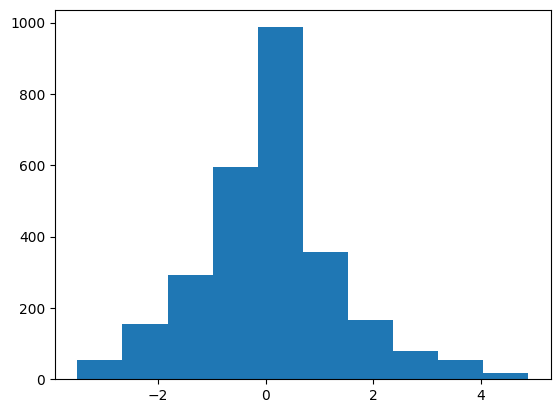

In [7]:
plt.hist(df_test_t_test.prediction - df_test_t_rl_test.prediction)

In [8]:
df_test_t = pd.concat([df_test_t_test, df_test_t_rl_test])

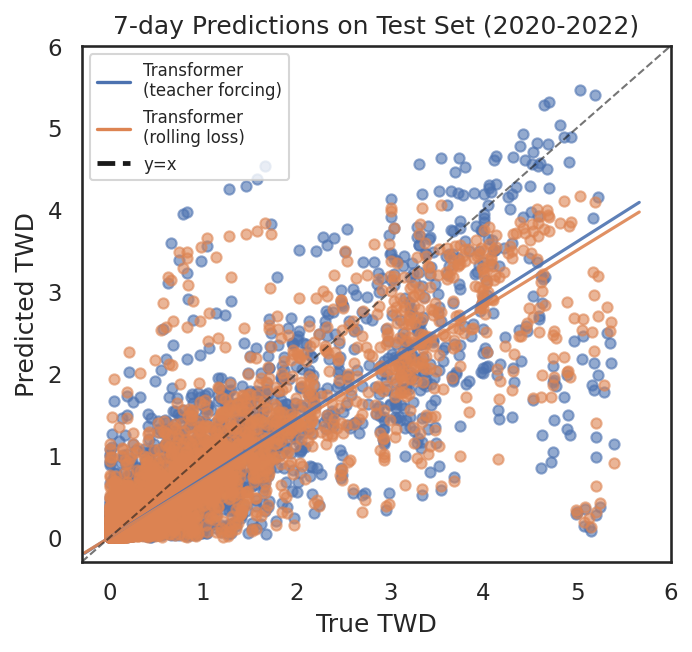

In [9]:
sns.set_theme(style="white", rc={"figure.dpi": 150})
palette = sns.color_palette()[0:2]
grid = sns.lmplot(data=df_test_t, x="actual", y="prediction", hue="model",
                  palette=palette, fit_reg=False, legend=False,
                  scatter_kws={"alpha": 0.6, "s": 24},
                  height=4.3, aspect=1.1)  # explicit size (height inches, width = height*aspect)
# grid.fig.set_size_inches(5.0, 4.0)  # enforce final size
ax = grid.axes[0, 0]
ax.set_facecolor("white")   
sns.despine(ax=ax)
xs = np.array(ax.get_xlim())

ax.set_xlabel("True TWD")
ax.set_ylabel("Predicted TWD")
ax.set_title("7-day Predictions on Test Set (2020-2022)", fontsize=12)
ax.set_xlim(-0.3, 6)
ax.set_ylim(-0.3, 6)
# force regression lines through origin for each model
for model, color in zip(df_test_t['model'].unique(), palette):
    sub = df_test_t[df_test_t['model'] == model]
    slope = (sub['actual'] * sub['prediction']).sum() / (sub['actual'] ** 2).sum()
    ax.plot(xs, slope * xs, color=color, linestyle='-', linewidth=1.5, alpha=0.9)

# 1:1 reference line through origin
ax.axline((0, 0), (5, 5), color="k", linestyle="--", linewidth=1, alpha=0.6)
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(True)
# custom legend
handles = [
    Line2D([0], [0], color=palette[0], lw=1.6, label="Transformer\n(teacher forcing)"),
    Line2D([0], [0], color=palette[1], lw=1.6, label="Transformer\n(rolling loss)"),
    Line2D([0], [0], color="k", lw=2.3, linestyle="--", label="y=x")
]
ax.legend(handles=handles, title="", 
# bbox_to_anchor=(0.5, 0.55),
 loc="best", ncol=1,
          fontsize=8, title_fontsize=8)
fig= grid.fig
fig.savefig(os.path.join(plot_path, "transformer_teacher_forcing_vs_rolling_loss.png"),
bbox_inches="tight", dpi=200)

In [10]:
df_test_t_rl_final = df_test_transformer_rl.loc[(df_test_transformer_rl['prediction_type'] == 'recursive_7day') & (df_test_transformer_rl['test_set'] == 'final') & (df_test_transformer_rl.actual <= 6), ]
rmse_final = root_mean_squared_error(df_test_t_rl_final['actual'], df_test_t_rl_final['prediction'])
r2_final = r2_score(df_test_t_rl_final['actual'], df_test_t_rl_final['prediction'])
print(f"Final Test Set RMSE (rolling loss model, 7-day recursive): {rmse_final:.3f}")
print(f"Final Test Set R2 (rolling loss model, 7-day recursive): {r2_final:.3f}")

Final Test Set RMSE (rolling loss model, 7-day recursive): 0.581
Final Test Set R2 (rolling loss model, 7-day recursive): 0.531


In [95]:
sns.color_palette("Set2")[2]

(0.5529411764705883, 0.6274509803921569, 0.796078431372549)

/tmp/ipykernel_3795560/760687259.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(x_range, x_range, 'k--', lw=2, color="tab:orange")
/tmp/ipykernel_3795560/760687259.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(x_range, [i+rmse_final for i in x_range], 'k--', lw=2, color="gold")
/tmp/ipykernel_3795560/760687259.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax1.plot(x_range, [i-rmse_final for i in x_range], 'k--', lw=2, color="gold")


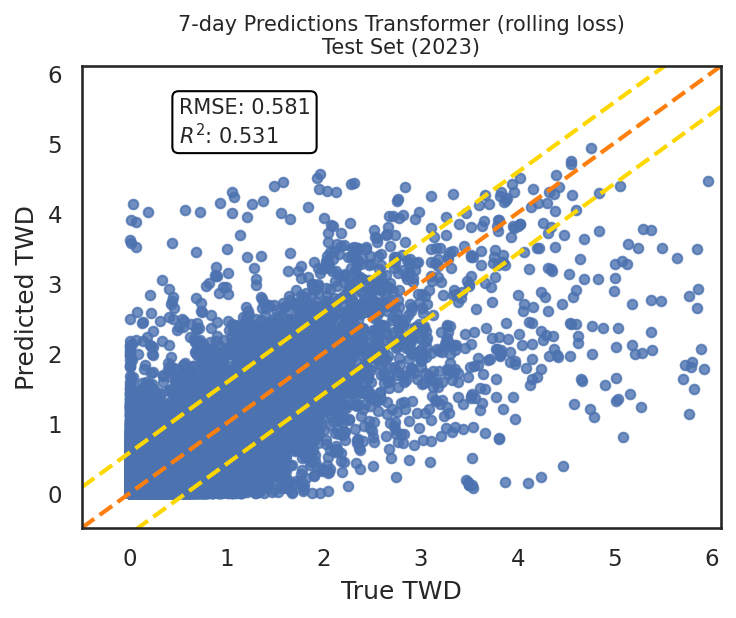

In [11]:
x_range = [-0.5, 6.1]
sns.set_theme(style="white")

fig, ax1 = plt.subplots(1, 1, figsize=(5.5,4), dpi = 150)
ax1.scatter(df_test_t_rl_final['actual'], df_test_t_rl_final['prediction'],
s = 21, color = sns.color_palette()[0],alpha = 0.8)
ax1.set_xlim(-0.5, 6.1)
ax1.set_ylim(-0.5, 6.1)
ax1.set_title("7-day Predictions Transformer (rolling loss)\nTest Set (2023)", fontsize=10)
ax1.text(0.5, 5, f"RMSE: {rmse_final:.3f}\n$R^{2}$: {r2_final:.3f}",
fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
ax1.plot(x_range, x_range, 'k--', lw=2, color="tab:orange")
ax1.plot(x_range, [i+rmse_final for i in x_range], 'k--', lw=2, color="gold")
ax1.plot(x_range, [i-rmse_final for i in x_range], 'k--', lw=2, color="gold")
ax1.set_xlabel("True TWD")
ax1.set_ylabel("Predicted TWD")
fig.savefig(os.path.join(plot_path, "transformer_rolling_loss_performance_capped.png"))

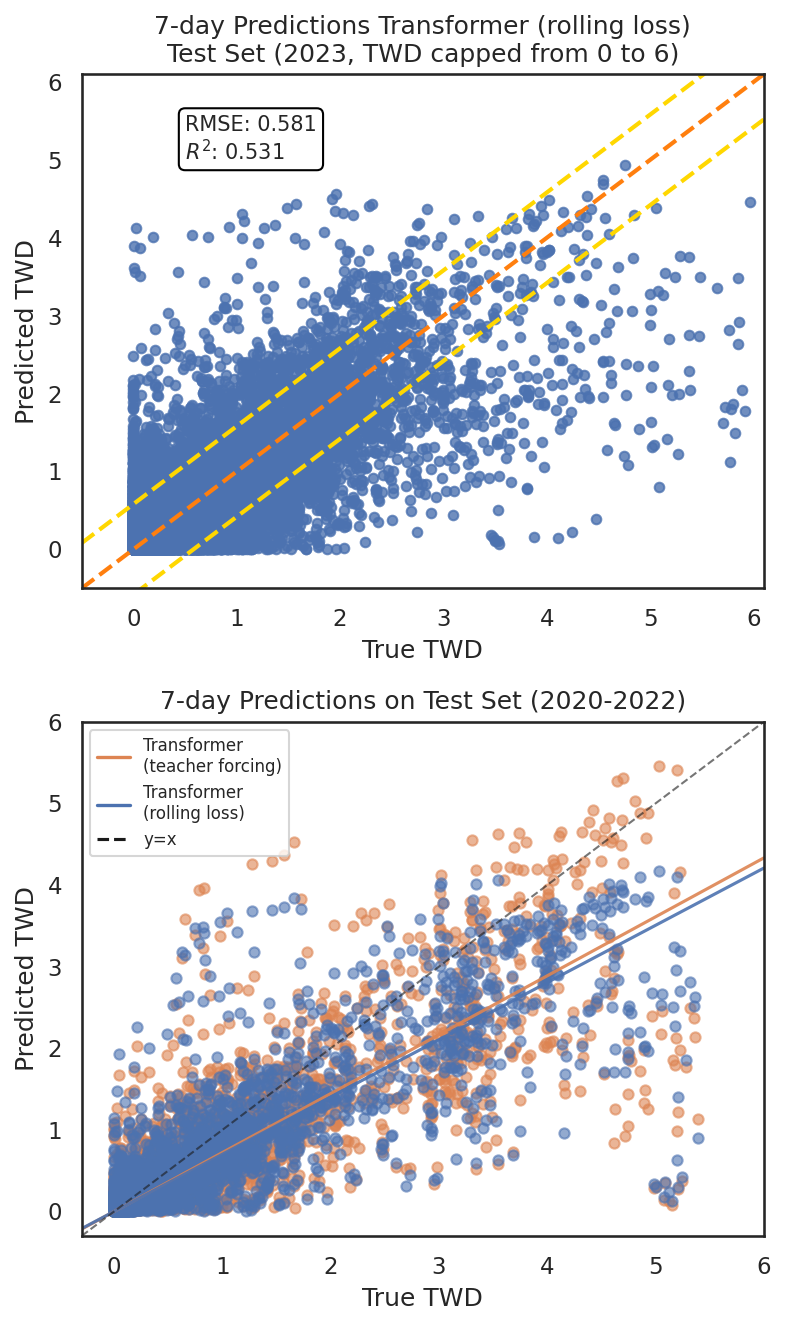

In [20]:
sns.set_theme(style="white", rc={"figure.dpi": 150})
palette =[sns.color_palette()[1], sns.color_palette()[0]]
x_range = [-0.5, 6.1]

fig, (ax2, ax1) = plt.subplots(2, 1, figsize=(5.4, 9), dpi=150)

# ── LEFT: teacher forcing vs rolling loss (test set 2021-2023) ──────────────
for model, color in zip(df_test_t['model'].unique(), palette):
    sub = df_test_t[df_test_t['model'] == model]
    ax1.scatter(sub['actual'], sub['prediction'],
                color=color, alpha=0.6, s=24, label=model)
    slope = (sub['actual'] * sub['prediction']).sum() / (sub['actual'] ** 2).sum()
    xs = np.array([-0.3, 6])
    ax1.plot(xs, slope * xs, color=color, linestyle='-', linewidth=1.5, alpha=0.9)

ax1.axline((0, 0), (5, 5), color="k", linestyle="--", linewidth=1, alpha=0.6)
ax1.set_xlim(-0.3, 6)
ax1.set_ylim(-0.3, 6)
ax1.set_xlabel("True TWD")
ax1.set_ylabel("Predicted TWD")
ax1.set_title("7-day Predictions on Test Set (2020-2022)", fontsize=12)
for spine in ["top", "right", "bottom", "left"]:
    ax1.spines[spine].set_visible(True)

handles = [
    Line2D([0], [0], color=palette[0], lw=1.6, label="Transformer\n(teacher forcing)"),
    Line2D([0], [0], color=palette[1], lw=1.6, label="Transformer\n(rolling loss)"),
    Line2D([0], [0], color="k", lw=1.5, linestyle="--", label="y=x")
]
ax1.legend(handles=handles, loc="best", ncol=1, fontsize=8)

# ── RIGHT: rolling loss final test set (2024) ───────────────────────────────
ax2.scatter(df_test_t_rl_final['actual'], df_test_t_rl_final['prediction'],
            s=21, color=palette[1], alpha=0.8)
ax2.set_xlim(-0.5, 6.1)
ax2.set_ylim(-0.5, 6.1)
ax2.set_title("7-day Predictions Transformer (rolling loss)\nTest Set (2023, TWD capped from 0 to 6)", fontsize=12)
ax2.text(0.5, 5, f"RMSE: {rmse_final:.3f}\n$R^{{2}}$: {r2_final:.3f}",
         fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
ax2.plot(x_range, x_range, '--', lw=2, color="tab:orange")
ax2.plot(x_range, [i + rmse_final for i in x_range], '--', lw=2, color="gold")
ax2.plot(x_range, [i - rmse_final for i in x_range], '--', lw=2, color="gold")
ax2.set_xlabel("True TWD")
ax2.set_ylabel("Predicted TWD")

fig.tight_layout()
fig.savefig(os.path.join(plot_path, "transformer_combined.png"), dpi=200)

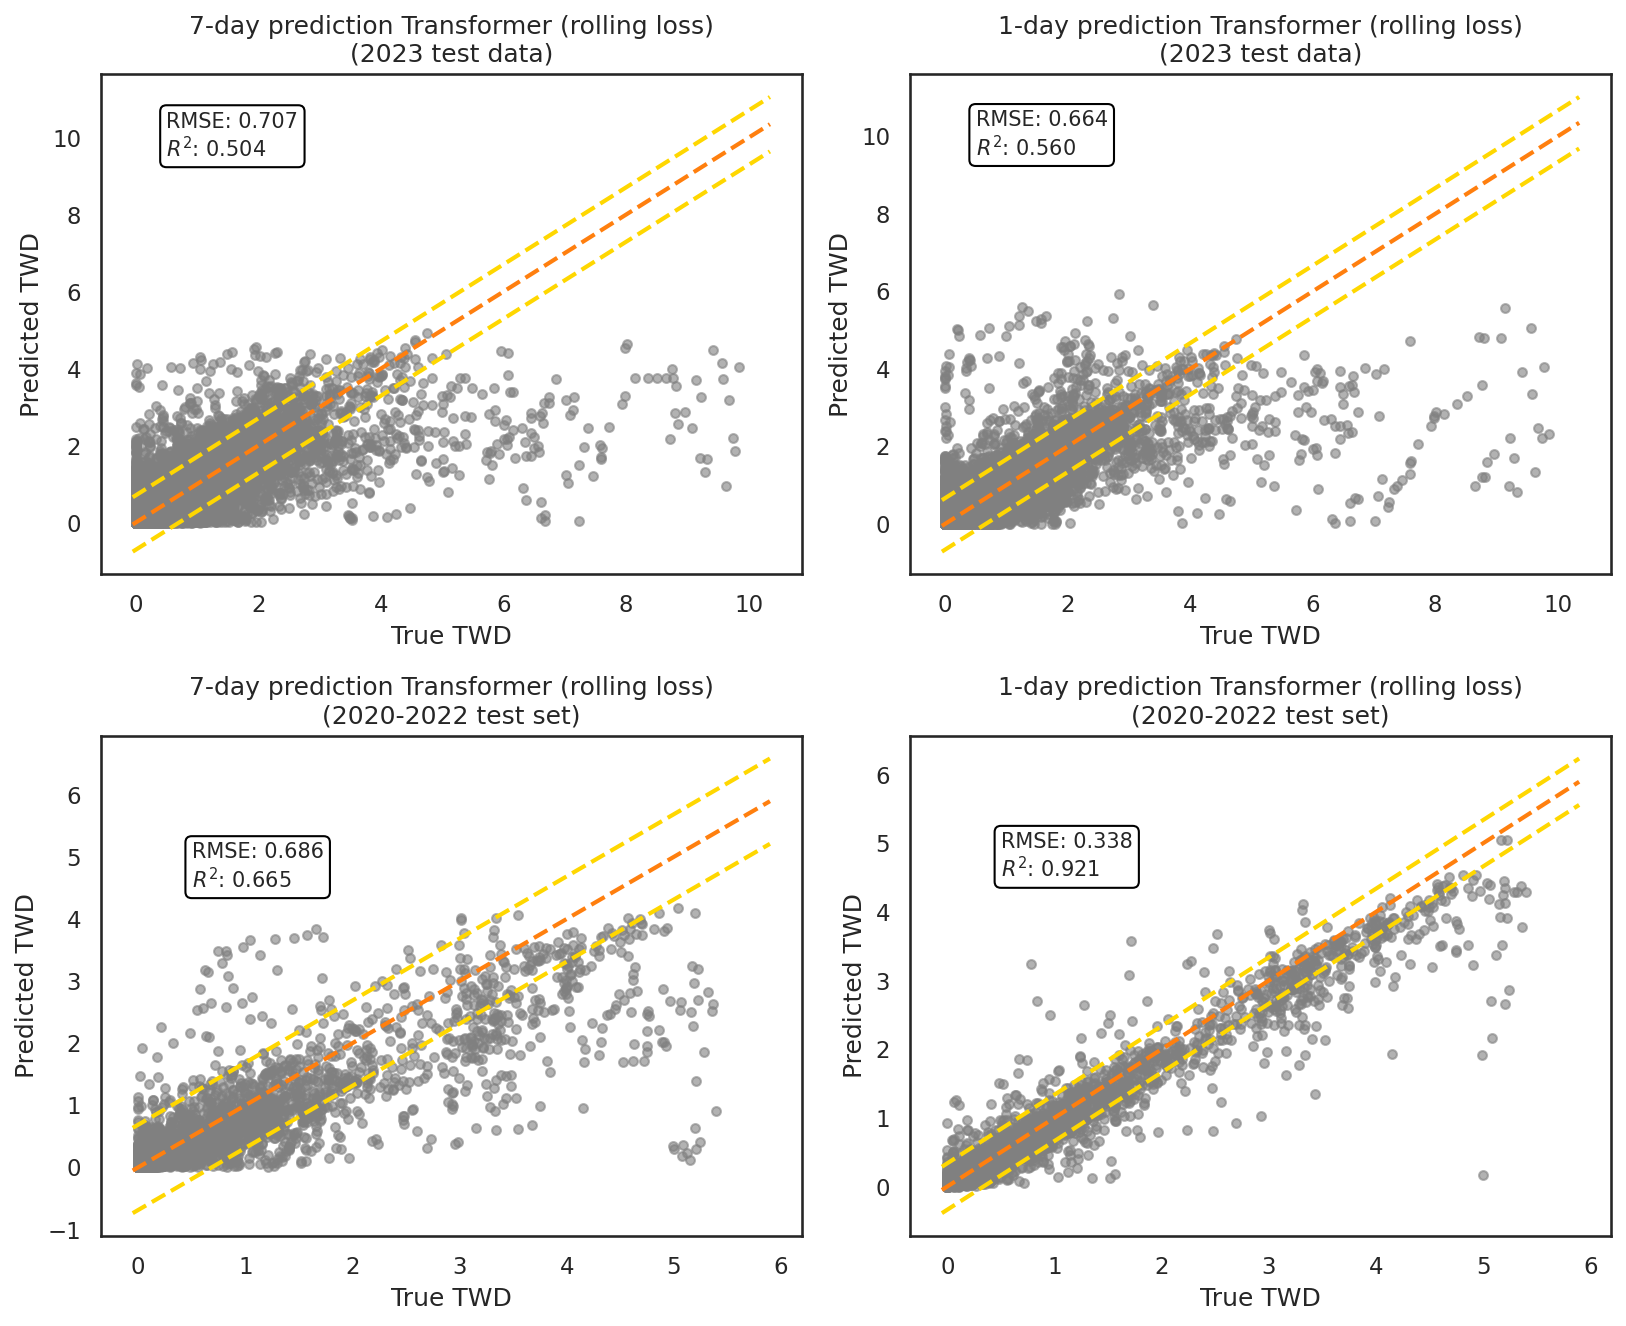

In [13]:

# ── extract arrays from saved CSV ──────────────────────────────────────────
_7d_final  = df_test_transformer_rl[(df_test_transformer_rl['prediction_type'] == 'recursive_7day') & (df_test_transformer_rl['test_set'] == 'final')]
_1d_final  = df_test_transformer_rl[(df_test_transformer_rl['prediction_type'] == '1day')           & (df_test_transformer_rl['test_set'] == 'final_test')]
_7d_test   = df_test_transformer_rl[(df_test_transformer_rl['prediction_type'] == 'recursive_7day') & (df_test_transformer_rl['test_set'] == 'test')]
_1d_test   = df_test_transformer_rl[(df_test_transformer_rl['prediction_type'] == '1day')           & (df_test_transformer_rl['test_set'] == 'test')]

y_final_at,     y_pred_final_at  = _7d_final['actual'].values,  _7d_final['prediction'].values
actuals_final,  preds_final      = _1d_final['actual'].values,  _1d_final['prediction'].values
y_test_at,      y_pred_test_at   = _7d_test['actual'].values,   _7d_test['prediction'].values
actuals_test,   preds_test       = _1d_test['actual'].values,   _1d_test['prediction'].values

rmse_at_final    = root_mean_squared_error(y_final_at,    y_pred_final_at)
r2_at_final      = r2_score(y_final_at,    y_pred_final_at)
rmse_final_1day  = root_mean_squared_error(actuals_final, preds_final)
r2_final_1day    = r2_score(actuals_final, preds_final)
rmse_test_at     = root_mean_squared_error(y_test_at,     y_pred_test_at)
r2_test_at       = r2_score(y_test_at,     y_pred_test_at)
rmse_test_1day   = root_mean_squared_error(actuals_test,  preds_test)
r2_test_1day     = r2_score(actuals_test,  preds_test)

# ── 2x2 plot ───────────────────────────────────────────────────────────────
sns.set_theme(style="white")
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(11, 9), dpi=150)
fig.subplots_adjust(wspace=0.2, hspace=0.3)

x_range_final_test = [float(y_final_at.min()) - 0.05, float(y_final_at.max()) + 0.5]
x_range_test       = [float(actuals_test.min()) - 0.05, float(actuals_test.max()) + 0.5]

def _scatter_panel(ax, actual, pred, rmse, r2, x_range, title, text_y):
    ax.scatter(actual, pred, color="grey", alpha=0.6, s=18)
    ax.plot(x_range, x_range,                               color="tab:orange", linestyle="--", lw=2)
    ax.plot(x_range, [i + rmse for i in x_range],           color="gold",       linestyle="--", lw=2)
    ax.plot(x_range, [i - rmse for i in x_range],           color="gold",       linestyle="--", lw=2)
    ax.text(0.5, text_y, f"RMSE: {rmse:.3f}\n$R^2$: {r2:.3f}",
            fontsize=10, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
    ax.set_xlabel("True TWD")
    ax.set_ylabel("Predicted TWD")
    ax.set_title(title)

_scatter_panel(ax1, y_final_at,    y_pred_final_at, rmse_at_final,   r2_at_final,
               x_range_final_test, "7-day prediction Transformer (rolling loss)\n(2023 test data)",       text_y=9.5)
_scatter_panel(ax2, actuals_final, preds_final,      rmse_final_1day, r2_final_1day,
               x_range_final_test, "1-day prediction Transformer (rolling loss)\n(2023 test data)",       text_y=9.5)
_scatter_panel(ax3, y_test_at,     y_pred_test_at,   rmse_test_at,    r2_test_at,
               x_range_test,       "7-day prediction Transformer (rolling loss)\n(2020-2022 test set)",   text_y=4.5)
_scatter_panel(ax4, actuals_test,  preds_test,        rmse_test_1day,  r2_test_1day,
               x_range_test,       "1-day prediction Transformer (rolling loss)\n(2020-2022 test set)",   text_y=4.5)

plt.tight_layout()
fig.savefig(os.path.join(plot_path, "Transformer_rolling_loss_final_performance_tight.png"), bbox_inches="tight", dpi=300)
plt.show()
